## Author: Aesha Gandhi ##

# Matching Exercise 

You have been hired by a mortgage firm (a company that both issues and collects mortgage payments from homeowners). This servicing firm is thinking about entering the market for "no money down" mortgages — mortgages in which the buyer does not have to pay a large percentage of the value of the house when they take out the loan (in the US, most people pay 20% of the value of a house up front when taking out a mortgage). Instead, they just pay a slightly higher interest rate.

Before they start offering this product, though, they want to know the effect this option will have on the likelihood people who take out a mortgage from them will make their payments. In other words, they want to know:

**What is the effect of a mortgage being issued as a "no money down" mortgage on the likelihood that the mortgage will enter delinquency (the homeowner will be at least 30 days late on a mortgage payment) during the first two years of the mortgage?**

On the one hand, we might expect that someone taking out a "no money down" mortgage would be *less* likely to enter delinquency because they didn't have to put a lot of cash into a down payment, making it easier for them to afford their payments. 

On the other hand, the kind of people who can put 20% down on a house are the kind of people who are able to save effectively, so someone who opts for a "no money down" mortgage with a higher interest rate (instead of saving to pay the 20% down payment) may be more likely to also struggle to make their regular payments. 

### Data

To answer this question, you have been given [REAL data on a sample of all US Standard single family home mortgages purchased or insured by Freddie Mac](https://www.freddiemac.com/research/datasets/sf-loanlevel-dataset). This is a random sample of standard mortgages issued in the calendar year 2004.


## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_matching.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex3_shr_delinquent_nmd",
    "ex3_shr_delinquent_regular",
    "ex4_share_nmd",
    "ex6_nmd_regression",
    "ex9_least_balanced",
    "ex11_matched_data",
    "ex11_num_no_money_down",
    "ex12_bivariate_effect",
    "ex13_withcoefficients_effect",
}
```

### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.

In [28]:
import pandas as pd
import numpy as np

# !pip install pyarrow

## Data Prep

### Exercise 1

To save you some time and let you focus on matching, I've done some pre-cleaning of this data a little. Later on this semester I'll ask you to work with a raw-er and more complete version of this data, but for now, please download the mortgage data here from [https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet](https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet).


In [29]:
url = "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/mortgages/exercise_matching/standard_mortgages.parquet"
df = pd.read_parquet(url)
df.head()

,Loan Sequence Number,Original Loan-to-Value (LTV),Original UPB,Original Loan Term,Credit Score,First Payment Date,First Time Homebuyer Flag,Original Interest Rate,Metropolitan Statistical Area (MSA) Or Metropolitan Division,Postal Code,delinquent
0,F04Q10000054,87,127000,360,653,200403,Y,6.050,20740.0,54700,0
1,F04Q10000200,70,121000,360,747,200403,N,6.125,30700.0,68500,0
2,F04Q10000236,80,286000,180,731,200403,N,5.125,NaN,60500,0
3,F04Q10000281,80,114000,180,682,200403,N,5.500,NaN,47100,0
4,F04Q10000296,80,132000,360,730,200403,N,5.750,NaN,81200,0


### Exercise 2

`Original Loan-to-Value (LTV)` is the share of the original value of the home that was borrowed. A value of 100 means there was no down payment ("no money down"), while higher values indicate a down payment was made. 

If you look at the values of `Original Loan-to-Value (LTV)` in the data, you will see there is a distribution of values. *Truly* no money down mortgages are actually pretty rare — about 1.4% of mortgages — but *almost* no money down mortgages (mortgages where the borrower only pays a 5% down payment) are a lot more common (about 10% of mortgages). So let's focus our analysis on those 95% LTV mortgages — they aren't *quite* no money down, but they're pretty close. From this point forward, when I say "no-money-down mortgages," I mean 95% LTV mortgages.

To keep things simple, let's compare these (almost) no money down mortgages to mortgages with a 20% down payment (LTV value of 80). This is the modal mortgage in the US. 

Once you've limited your data to mortgages with LTVs of 95% and 80%, what share of the mortgages you still have were no-money-down (LTV 95%) mortgages? Store your answer under the key `"ex2_share_nmd"`.

In [30]:
data = df[
    (df["Original Loan-to-Value (LTV)"] == 80)
    | (df["Original Loan-to-Value (LTV)"] == 95)
]
results = {}
data["Type"] = np.where(data["Original Loan-to-Value (LTV)"] == 80, "Regular", "NMD")
share_95 = np.count_nonzero(data["Type"] == "NMD") / len(data)
results["ex2_share_nmd"] = share_95
print("")
print("Share of 95% LTV loans: ", share_95)


Share of 95% LTV loans:  0.19942642841385397


In [31]:
data.head()

,Loan Sequence Number,Original Loan-to-Value (LTV),Original UPB,Original Loan Term,Credit Score,First Payment Date,First Time Homebuyer Flag,Original Interest Rate,Metropolitan Statistical Area (MSA) Or Metropolitan Division,Postal Code,delinquent,Type
2,F04Q10000236,80,286000,180,731,200403,N,5.125,NaN,60500,0,Regular
3,F04Q10000281,80,114000,180,682,200403,N,5.500,NaN,47100,0,Regular
4,F04Q10000296,80,132000,360,730,200403,N,5.750,NaN,81200,0,Regular
5,F04Q10000522,80,69000,360,791,200403,N,5.875,45060.0,13200,0,Regular
6,F04Q10001309,80,88000,240,739,200403,N,5.750,NaN,54600,0,Regular


### Exercise 3

Now let's see how delinquency rates compare between regular and no-money-down mortgages. Store the share of mortgages that are ever delinquent under the keys `"ex3_shr_delinquent_regular"` and `"ex3_shr_delinquent_nmd"`

In [32]:
delinquent_regular = data[(data["Type"] == "Regular") & (data["delinquent"] == 1)]
delinquent_nmd = data[(data["Type"] == "NMD") & (data["delinquent"] == 1)]
share_delinquent_regular = len(delinquent_regular) / len(
    data[data["Type"] == "Regular"]
)
share_delinquent_nmd = len(delinquent_nmd) / len(data[data["Type"] == "NMD"])
results["ex3_shr_delinquent_regular"] = share_delinquent_regular
results["ex3_shr_delinquent_nmd"] = share_delinquent_nmd
print("Share of delinquent loans among regular loans: ", share_delinquent_regular)
print("Share of delinquent loans among NMD loans: ", share_delinquent_nmd)

Share of delinquent loans among regular loans:  0.06337834114081015
Share of delinquent loans among NMD loans:  0.1338495575221239


### Exercise 4

Now, is this difference the result of not having to put money down, or is it the result of different lending standards? 

Let's take a look at a few descriptive statistics to try and answer this question. 

First, plot two histograms on the same plot — one with the credit score for regular mortgage borrowers, and one with the credit score for no-money-down mortgage borrowers. Then do the same with the size of the mortgage (`"Original UPB"`) and original interest rates (`"Original Interest Rate"`).

Make sure you're plotting densities not frequencies. 

Do these look like the same borrowers? (High credit scores mean people are deemed to be at lower risk of defaulting on their loans).

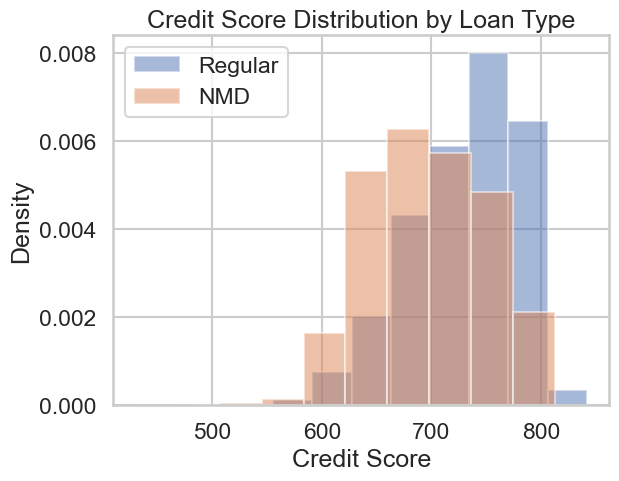

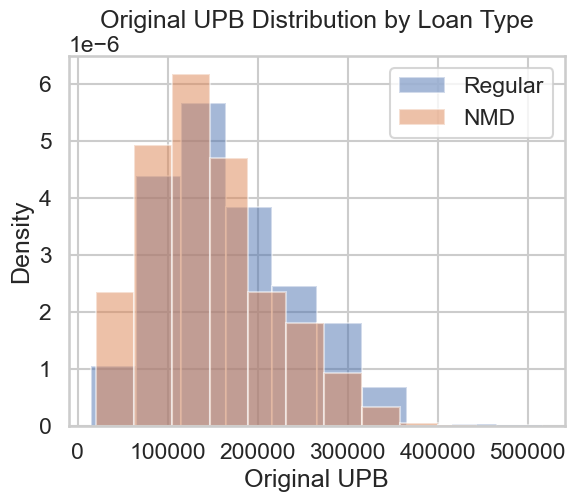

In [33]:
# plot credit score distribution for regular and NMD loans, plot density not freq
import matplotlib.pyplot as plt

plt.hist(
    data[data["Type"] == "Regular"]["Credit Score"],
    alpha=0.5,
    label="Regular",
    density=True,
)
plt.hist(
    data[data["Type"] == "NMD"]["Credit Score"], alpha=0.5, label="NMD", density=True
)
plt.legend()
plt.title("Credit Score Distribution by Loan Type")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

# plot size of mortgage ("Original UPB") and original interest rates ("Original Interest Rate") for regular and NMD loans, plot density not freq
plt.hist(
    data[data["Type"] == "Regular"]["Original UPB"],
    alpha=0.5,
    label="Regular",
    density=True,
)
plt.hist(
    data[data["Type"] == "NMD"]["Original UPB"], alpha=0.5, label="NMD", density=True
)
plt.legend()
plt.title("Original UPB Distribution by Loan Type")
plt.xlabel("Original UPB")
plt.ylabel("Density")
plt.show()

### Exercise 5

Matching brings value when you have an imbalance in covariates between your control and treatment groups. At the same time, matching only works when there isn't too much imbalance — you need an area of "common support" where you have both control and treatment observations for certain ranges of your covariates. 

Looking back at your results from Exercise 6, does it seem like this data might be a good candidate for matching?

**This is a good candidate for matching because there is overlap for the credit scores and loan amounts between Regular and No Money Down options, while there are still shifted distributions, i.e. not completely the same as seen in the histogram. The previous problem would suggest naively that regular loans are about 7% less likely to become delinquent (6% vs 13%) than NMD. There could be selection bias in which people don't randomly get NMD mortgages, but rather the those who tend to qualify or choose NMD are likely to be systematically different from regular borrowers, which is also why matching could be good. The histogram shows NMD having slightly lower UPD distributions and credit score distributions than regular.**

### Exercise 6

To establish a baseline of sorts, regress your "delinquent" variable on:

- whether the loan is a no-money-down mortgage, 
- borrower credit score,
- whether borrower is a first time home buyer, and 
- the original interest rate. 

Use a linear model and (because the dependent variable is 0-1) heteroskedastic robust standard errors. Store the estimated effect of a mortgage being no-money-down (the coefficient on no-money-down indicator) in `results` under the key `ex6_nmd_regression`.

(Note: if you use the formula api from statsmodels, you may have to change some variable names)

In [34]:
import statsmodels.api as sm

data["NMD"] = (data["Type"] == "NMD").astype(int)
data = data[data["First Time Homebuyer Flag"] != "9"]
X = data[
    ["NMD", "Credit Score", "First Time Homebuyer Flag", "Original Interest Rate"]
].copy()

X["First Time Homebuyer Flag"] = (X["First Time Homebuyer Flag"] == "Y").astype(int)

X = sm.add_constant(X)

y = data["delinquent"]

model = sm.OLS(y, X).fit(cov_type="HC1")

results["ex6_nmd_regression"] = model.params["NMD"]

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     66.66
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.13e-55
Time:                        10:11:49   Log-Likelihood:                -695.44
No. Observations:                9063   AIC:                             1401.
Df Residuals:                    9058   BIC:                             1436.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### Exercise 7

Matching is great because of its ability to reduce dependence on functional form assumptions (do you assume the dependent variable increases linearly with the dependent variable, or the log of the dependent variable, or the square, etc.). This is most powerful where there is some "extrapolation" taking place because of an imbalance in covariates, because there's no good way to validate those extrapolations. But it also simplifies the general problem of worrying about function forms.

To illustrate, we just fit our model with a range of covariates included as linear controls. But do we know that delinquency decreases linearly with credit scores? 

Just looking at delinquency and credit scores, fit a lowess regression (or other model with a flexible functional form) to see if that relationship is indeed linear. 

Now do the same for delinquency and the original interest rate. Does that seem linear?

What does this tell you about the accuracy of your regression estimates above?

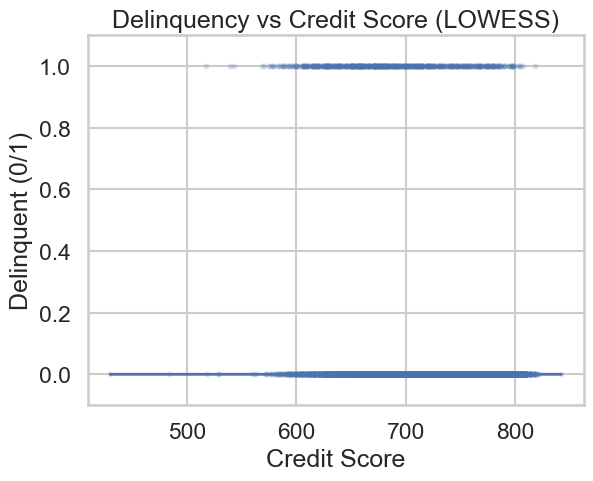

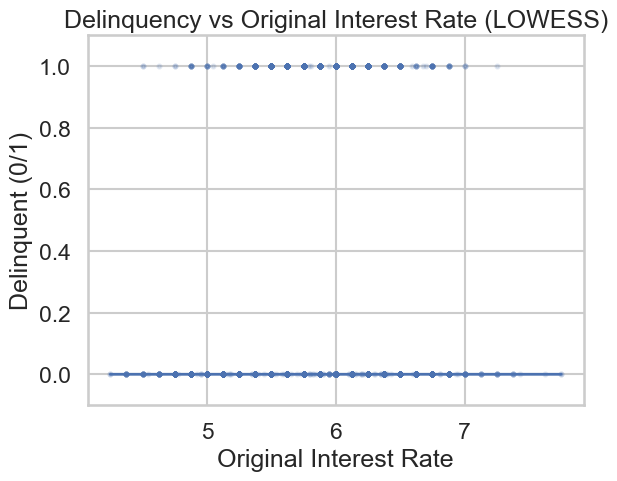

In [35]:
frac = 0.25

lowess_cs = sm.nonparametric.lowess(
    endog=data["delinquent"].values,
    exog=data["Credit Score"].values,
    frac=frac,
    return_sorted=True,
)

lowess_ir = sm.nonparametric.lowess(
    endog=data["delinquent"].values,
    exog=data["Original Interest Rate"].values,
    frac=frac,
    return_sorted=True,
)

y = data["delinquent"].values
plt.figure()
plt.scatter(data["Credit Score"].values, y, s=8, alpha=0.15)

plt.plot(lowess_cs[:, 0], lowess_cs[:, 1], linewidth=2)
plt.title("Delinquency vs Credit Score (LOWESS)")
plt.xlabel("Credit Score")
plt.ylabel("Delinquent (0/1)")
plt.ylim(-0.1, 1.1)
plt.show()


plt.figure()
plt.scatter(data["Original Interest Rate"].values, y, s=8, alpha=0.15)
plt.plot(lowess_ir[:, 0], lowess_ir[:, 1], linewidth=2)
plt.title("Delinquency vs Original Interest Rate (LOWESS)")
plt.xlabel("Original Interest Rate")
plt.ylabel("Delinquent (0/1)")
plt.ylim(-0.1, 1.1)
plt.show()

**The lowess plots show that the relationships for delinquency and credit score and interest rate look decently linear, so using the linear regression is appropriate as there aren't functional form errors.** 

## Matching!

OK, let's finally do some matching!

To do our matching, we will be using pymatchit, a port of the exceptionally good [MatchIt](https://kosukeimai.github.io/MatchIt/index.html) which is only natively available in R. [It supports genetic matching, exact matching, coarsened exact matching, nearest neighbor matching, subclass matching, cardinality matching, and more.](https://kosukeimai.github.io/MatchIt/articles/matching-methods.html). 

This library was just recently created (and I have to imagine with significant LLM help), so it's a little early to be using it. With that said, matching is one area where R packages (namely MatchIt) are still well ahead of Python libraries, and after looking things over pretty carefully it seems well implemented — it has a reasonable test suite, includes diagnostic plots (which are something that's so often missing from Python matching and are great for learning), and testing the matching algorithm we're using (coarse exact matching) things seem to match between R and this package. So let's try it. :)

So install it with `pip install pymatchit-causal` (**not** `pip install pymatchit`), and quickly review the [README for the repo here](https://github.com/jtuenner/).


In [36]:
# !pip install pymatchit-causal

### Exercise 8

Let's do some coarsened exact matching. 

In particular, we will match on `credit_score`, `original_interest_rate`, and `first_time_homebuyer_flag`.

Recall that with coarsened exact matching, we have to specify how continuous variables (like `credit_score` and `original_interest_rate`) should be coarsened. This is accomplished with the `cutpoints` keyword. Note the `cutpoints` takes the upper and lower values to be bounds — so `[1, 2, 3]` will create two groups: between 1 and 2 and between 2 and 3. Values below 1 and above 3 will be dropped.

```python
from pymatchit import MatchIt

mortgages["first_time"] = (mortgages["first_time_homebuyer_flag"] == "Y").astype("int")

# Deterministic sort to ensure
# random seed generates same result
mortgages = mortgages.sort_values("loan_sequence_number")

m = MatchIt(
    data=mortgages,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
        "original_interest_rate": [4.25, 5.25, 6.25, 7.25, 8.25],
    },
)


# Format: treatment_variable ~ covariate1 + covariate2 + ...
m.fit("no_money_down ~ credit_score + original_interest_rate " "+ first_time")

```



In [37]:
from pymatchit import MatchIt

mortgages = data.copy()

# make column names patsy-friendly
mortgages = mortgages.rename(
    columns={
        "Credit Score": "credit_score",
        "Original Interest Rate": "orig_interest_rate",
        "First Time Homebuyer Flag": "first_time_flag",
    }
)

mortgages["first_time"] = (mortgages["first_time_flag"] == "Y").astype(int)

mortgages = mortgages.sort_values("Loan Sequence Number")

m = MatchIt(
    data=mortgages,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints={
        "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
        "orig_interest_rate": [4.25, 5.25, 6.25, 7.25, 8.25],
    },
)

m.fit("NMD ~ credit_score + orig_interest_rate + first_time")

Performing cem matching (ATE)...
Matching complete. 8819 observations in matched set.


### Exercise 9

The first thing to do after matching is to see if the merge worked well. 

Use `m.plot(type="balance", threshold=0.2)` to see how balanced the matched coefficients look. Which variable appears not to be that well balanced in the matched data? Store your answer as a string in `"ex9_least_balanced"`

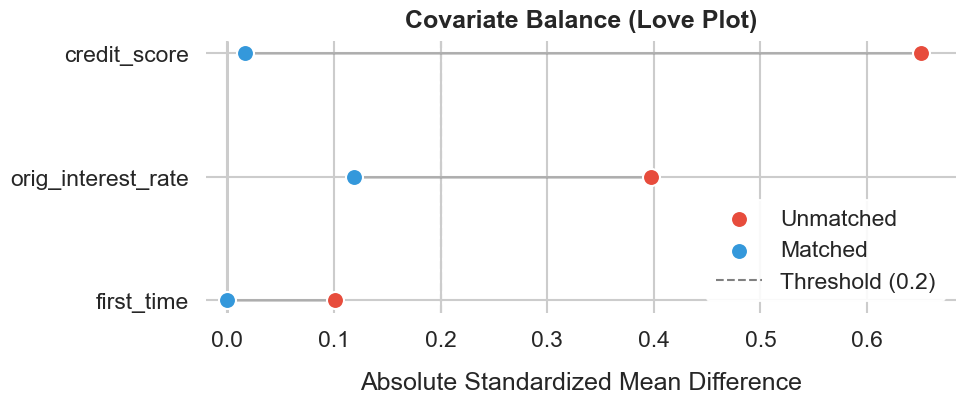

In [38]:
m.plot(type="balance", threshold=0.2)
results["ex9_least_balanced"] = "original_interest_rate"

### Exercise 10

Let's tighten up our cutpoints to try and get better matches on interest rates. Try:

```python

cutpoints={
    "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
    "original_interest_rate": np.arange(4.25, 8.1, 0.1),
}

```

Then check your balance plot.

Performing cem matching (ATE)...
Matching complete. 8430 observations in matched set.


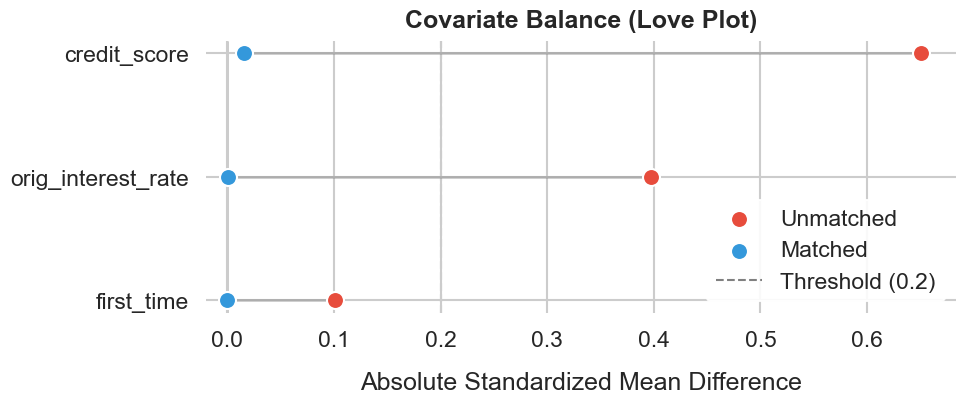

In [39]:
cutpoints = {
    "credit_score": [500, 575, 650, 675, 700, 720, 740, 760, 780, 800],
    "orig_interest_rate": np.arange(4.25, 8.1, 0.1),
}

m = MatchIt(
    data=mortgages,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints=cutpoints,
)

m.fit("NMD ~ credit_score + orig_interest_rate + first_time")
m.plot(type="balance", threshold=0.2)

### Exercise 11

Given we're still getting a lot of matched observations, so let's tighten credit ratings too! Try:

```python
cutpoints = {
    "credit_score": np.arange(500, 800, 20),
    "original_interest_rate": np.arange(4.25, 8.1, 0.1),
}
```

Store your final number of matches in `ex11_num_matches` (you can get this from `len(m.matched_data)`) and the final number of matched treated units (no money down mortgages) in `"ex11_num_no_money_down"`.

Performing cem matching (ATE)...
Matching complete. 7484 observations in matched set.


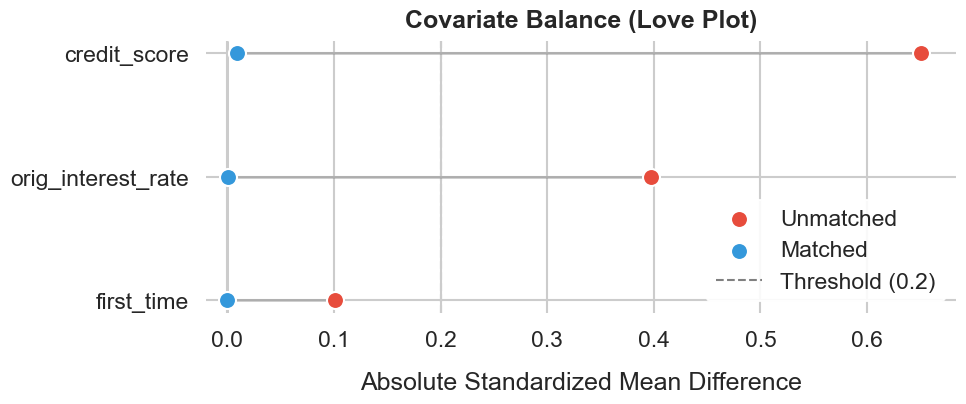

Number of matched observations:  7484
Number of matched treated units (NMD):  1644


In [40]:
cutpoints = {
    "credit_score": np.arange(500, 800, 20),
    "orig_interest_rate": np.arange(4.25, 8.1, 0.1),
}

m = MatchIt(
    data=mortgages,
    method="cem",
    replace=False,
    random_state=42,
    estimand="ATE",
    cutpoints=cutpoints,
)

m.fit("NMD ~ credit_score + orig_interest_rate + first_time")
m.plot(type="balance", threshold=0.2)
num_matches = len(m.matched_data)
print("Number of matched observations: ", num_matches)
results["ex11_num_matches"] = num_matches
# get final number of matched treated units (NMD)
num_treated = len(m.matched_data[m.matched_data["NMD"] == 1])
results["ex11_num_no_money_down"] = num_treated
print("Number of matched treated units (NMD): ", num_treated)

## Analyzing Matches

Assuming you feel ok with the matches at this point, let's do some analyses!

### Exercise 12

Using statsmodels, fit a weighted regression using the data in `m.matched_data` with just `no_money_down` as a regressor. Store the resulting coefficient in `"ex12_bivariate_effect"`.

Note that `pymatchit` can provide two different types of weights — weights for estimating ATE, and weights for estimating ATT. 

To estimate ATT, the weight of a treated (here, `no_money_down`) observation will always be 1, and the weight for a control observation will be the number of treatment observations in the coarse match group divided by the number of controls.

To estimate ATE, the weights are just the total observations in the coarse match group divided by number of treatment observations (for treated observations) and total observations in the coarse match group divided by the number of control observations (for control observations).

Here, we've specified the estimate is `"ATE"`, so we get weights for estimating ATE.


In [41]:
import statsmodels.api as sm

md = m.matched_data.copy()

treat_col = "NMD"

#
y = md["delinquent"].astype(float)

X = sm.add_constant(md[treat_col].astype(float))


w = md["weights"].astype(float)

fit = sm.WLS(y, X, weights=w).fit()
results["ex12_bivariate_effect"] = float(fit.params[treat_col])

print(fit.summary())

print("ex12_bivariate_effect =", results["ex12_bivariate_effect"])

                            WLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.003
Model:                            WLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     19.46
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.04e-05
Time:                        10:11:51   Log-Likelihood:                -1948.3
No. Observations:                7484   AIC:                             3901.
Df Residuals:                    7482   BIC:                             3914.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0727      0.005     15.798      0.0

**The estimated coeff on NMD is about -0.0275 which means that no money down mortagaes are associated with a 2.75 % lower probability of delinquency in the matched sample.**

### Exercise 13

Because not all our coefficients matched perfectly, its good practice to include the matching variables in your regression in their original form. So estimate your model again, this time with `no_money_down`, `credit_score`, `original_interest_rate` and `first_time` in the regression. Store the new estimated effect in `"ex13_withcoefficients_effect"`.

In [42]:
import statsmodels.api as sm

md = m.matched_data.copy()

y = md["delinquent"].astype(float)

X = sm.add_constant(
    md[["NMD", "credit_score", "orig_interest_rate", "first_time"]].astype(float)
)


w = md["weights"].astype(float)

fit = sm.WLS(y, X, weights=w).fit()
results["ex13_withcoefficients_effect"] = float(fit.params[treat_col])

print(fit.summary())

print("ex13_withcoefficients_effect =", results["ex13_withcoefficients_effect"])

                            WLS Regression Results                            
Dep. Variable:             delinquent   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     64.93
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           4.57e-54
Time:                        10:11:51   Log-Likelihood:                -1830.3
No. Observations:                7484   AIC:                             3671.
Df Residuals:                    7479   BIC:                             3705.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7686      0

**After re estimating the weighted regression with the original matching covariates along with NMD indicator, the coefficient stayed the same as -0.026. This shows that the estimated effect is stable after we controlled for these covariates (credit score, original interest rate, first time homebuyer). This reinforces what we said earlier that NMD mortages are associated with the reduction in delinquency in the matched data.**

In [43]:
results

{'ex2_share_nmd': np.float64(0.19942642841385397),
 'ex3_shr_delinquent_regular': 0.06337834114081015,
 'ex3_shr_delinquent_nmd': 0.1338495575221239,
 'ex6_nmd_regression': np.float64(0.03801489697146032),
 'ex9_least_balanced': 'original_interest_rate',
 'ex11_num_matches': 7484,
 'ex11_num_no_money_down': 1644,
 'ex12_bivariate_effect': 0.028721458895701935,
 'ex13_withcoefficients_effect': 0.028223263488233657}

In [44]:
assert set(results.keys()) == {
    "ex3_shr_delinquent_nmd",
    "ex3_shr_delinquent_regular",
    "ex2_share_nmd",
    "ex6_nmd_regression",
    "ex9_least_balanced",
    "ex11_num_matches",
    "ex11_num_no_money_down",
    "ex12_bivariate_effect",
    "ex13_withcoefficients_effect",
}